# **Employee Attrition and Performance Notebook**

**Problem:** Discovery if there is any significant variables that indeed affect employee attrition. rank the variables from most important to the least.
Dependent featyre **Attrition**



---



## **1. Understanding the data**

## **About Dataset**

*[Kagggle data card ](https://www.kaggle.com/pavansubhasht/ibm-hr-analytics-attrition-dataset):*

Explore this dataset and see if there are any significant variables that indeed affect employee attrition. Take it a step further and see if you can rank the variables from most important to the least.

Uncover the factors that lead to employee attrition and explore important questions such as ‘show me a breakdown of distance from home by job role and attrition’ or ‘compare average monthly income by education and attrition’. This is a fictional data set created by IBM data scientists.

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import chi2
from scipy.stats import f_oneway
from sklearn.preprocessing import LabelEncoder

# Deactivate warnings
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

In [90]:
df = pd.read_csv('/data.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [91]:
df.describe().astype(float).round(2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


### **Data Review**

On this section we will review the attrition dataset to undestand more about the data such as:

1. Describe the data for mininful insigths
2. Data Types to make sure the data types is relevant to the data description
3. Missing Data review
4. Data scale review

All of this information is imperative for Data Preprocessing.

#### Traget Column: Attrition
Contains Values:

1. NO
2. Yes

In [92]:
df['Attrition'].unique()

array(['Yes', 'No'], dtype=object)

In [93]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

<Axes: ylabel='Attrition'>

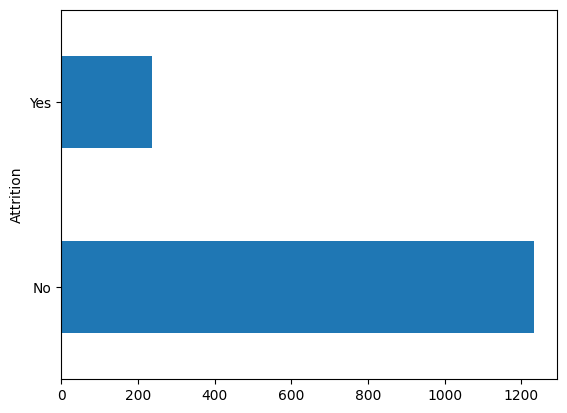

In [94]:
# Plot attrition column
y.value_counts().plot(kind='barh')


#### Data Types

Review of data types for all dataset

Also, quick review for null counts

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                



#### **Conclusion of this section**


The 35 features from the Employee Attrition dataset are devided on three groups:

1. Employee job related features
2. Employee personal data features
3. Employee job satisfaction feautres

Next actions:

1. Data Preprocessing, no nulls found


---





## **2. Data Visulization**

On this section we will review the features before data cleaning and preprocessing.

The idea is to get insights about each feature:

1. Data Distribution
2. Detect Patterns Visualy
3. Identify Data Quality Issues

### Dependent Feature (Attrition)



<Axes: ylabel='Attrition'>

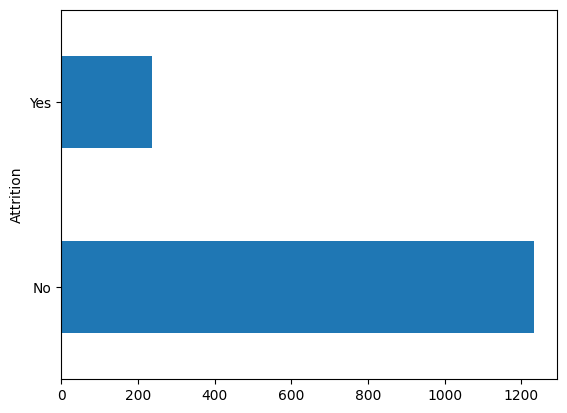

In [96]:
# Plot attrition column
y.value_counts().plot(kind='barh')


### Review percentage of Attrition counts

In [97]:
y_group = y.value_counts(normalize=True)
y_group

,proportion
Attrition,
No,0.838776
Yes,0.161224


### Review percentage of Attrition counts by Gender, Marital status & Work-life balance

Group by Gender

In [98]:
y_gender_attrition = df[df['Attrition'] == 'Yes'].groupby(['Gender']).size().reset_index(name='Attrition_Count')
y_gender_total = df.groupby(['Gender']).size().reset_index(name='Total_Population')

# Merge the two dataframes
gender_comparison = pd.merge(y_gender_attrition, y_gender_total, on='Gender', how='outer').fillna(0)

# Calculate the percentage of Attrition out of the total population
gender_comparison['Attrition_Percentage_of_Total'] = (gender_comparison['Attrition_Count'] / gender_comparison['Total_Population'])

gender_comparison.sort_values(by='Attrition_Percentage_of_Total', ascending=False)

,Gender,Attrition_Count,Total_Population,Attrition_Percentage_of_Total
1,Male,150,882,0.170068
0,Female,87,588,0.147959


Group by Marital Status

In [99]:
y_marital_attrition = df[df['Attrition'] == 'Yes'].groupby(['MaritalStatus']).size().reset_index(name='Attrition_Count')
y_marital_total = df.groupby(['MaritalStatus']).size().reset_index(name='Total_Population')

# Merge the two dataframes
marital_comparison = pd.merge(y_marital_attrition, y_marital_total, on='MaritalStatus', how='outer').fillna(0)

# Calculate the percentage of Attrition out of the total population
marital_comparison['Attrition_Percentage_of_Total'] = (marital_comparison['Attrition_Count'] / marital_comparison['Total_Population'])

marital_comparison.sort_values(by='Attrition_Percentage_of_Total', ascending=False)

,MaritalStatus,Attrition_Count,Total_Population,Attrition_Percentage_of_Total
2,Single,120,470,0.255319
1,Married,84,673,0.124814
0,Divorced,33,327,0.100917


Group by Worklife Balance

In [100]:
y_wl_attrition = df[df['Attrition'] == 'Yes'].groupby(['WorkLifeBalance']).size().reset_index(name='Attrition_Count')
y_wl_total = df.groupby(['WorkLifeBalance']).size().reset_index(name='Total_Population')

# Merge the two dataframes
wl_comparison = pd.merge(y_wl_attrition, y_wl_total, on='WorkLifeBalance', how='outer').fillna(0)

# Calculate the percentage of Attrition out of the total population
wl_comparison['Attrition_Percentage_of_Total'] = (wl_comparison['Attrition_Count'] / wl_comparison['Total_Population'])

wl_comparison.sort_values(by='Attrition_Percentage_of_Total', ascending=False)

,WorkLifeBalance,Attrition_Count,Total_Population,Attrition_Percentage_of_Total
0,1,25,80,0.312500
3,4,27,153,0.176471
1,2,58,344,0.168605
2,3,127,893,0.142217




#### **Conclusion of Vizualisation of Attrition (Dependent Feature)**


Exporing the distribution of the Attrition feature we found interesting insights:

1. Only 16% of the employess report attrition.
2. There is not significant difference on attrition percentage comparing genders.
3. Single employees report 25% of attrition, which compared to married or divorce the percentage oscilates around 10-12.
4. When work-life balance is bad, per the employee, the attrition percentge is 31, compared to the other categories (Good, Better, Best) the difference is significant as the other categories are less than 20%

Next actions:

1. Data Cleaning and Preprocessing: The weight group **?** represend a good amount of data of the entire dataset. Therefore, this should be treated as NULL values for correct preprocessing.
2. Data Visualization for the rest of the Independent variables's distribution exploration
---

## **3. Data Cleaning & Preprocessing**

On this section we will clean the data and preprocess for better performance compute.

Activities on this section:

1. Missing Values
2. Outliers
4. Feature Scaling

#### Handleling Missing Values

In [101]:
# Inspect null values
missing_val = df.columns[df.isnull().any()]
missing_val

Index([], dtype='object')

No Missing values were found

#### Outliers Detection & Handleling

For this project, we chose to detect outliers with Standard Deviation.

In [102]:
num_features = df.select_dtypes(include=['int64', 'float64']).columns
num_features

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [103]:
# There are some features as int/float but in reality are representation to categories.
# Update those columns to categorie type

to_cat = ['Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
          'WorkLifeBalance']
df[to_cat] = df[to_cat].astype('category')

# Recreate the num features list
num_features = df.select_dtypes(include=['int64', 'float64']).columns
num_features

Index(['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeCount', 'HourlyRate',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [104]:
# Numerical features were already stored in a variable
#
# We can now define the limits using +/- 3 sigmas per variable

limit_sigma = {}

for num in num_features:
 limit_sigma[num] = df[num].mean() - 3 * df[num].std(), df[num].mean() + 3 * df[num].std()


limit_sigma

{'Age': (np.float64(9.51768905639932), np.float64(64.32992999121973)),
 'DailyRate': (np.float64(-408.0415855448705), np.float64(2013.013014116299)),
 'DistanceFromHome': (np.float64(-15.128076300195534),
  np.float64(33.51311031380098)),
 'EmployeeCount': (np.float64(1.0), np.float64(1.0)),
 'HourlyRate': (np.float64(4.9028736805965565), np.float64(126.8794392445735)),
 'MonthlyIncome': (np.float64(-7620.939056776979),
  np.float64(20626.80164181099)),
 'MonthlyRate': (np.float64(-7040.254730819377),
  np.float64(35666.46153354047)),
 'NumCompaniesWorked': (np.float64(-4.800829739300689),
  np.float64(10.18722429712382)),
 'PercentSalaryHike': (np.float64(4.229710659904901),
  np.float64(26.189336959142715)),
 'StandardHours': (np.float64(80.0), np.float64(80.0)),
 'StockOptionLevel': (np.float64(-1.7623524527721015),
  np.float64(3.3501075548129178)),
 'TotalWorkingYears': (np.float64(-12.062753189810318),
  np.float64(34.62193686327971)),
 'TrainingTimesLastYear': (np.float64(-1.068

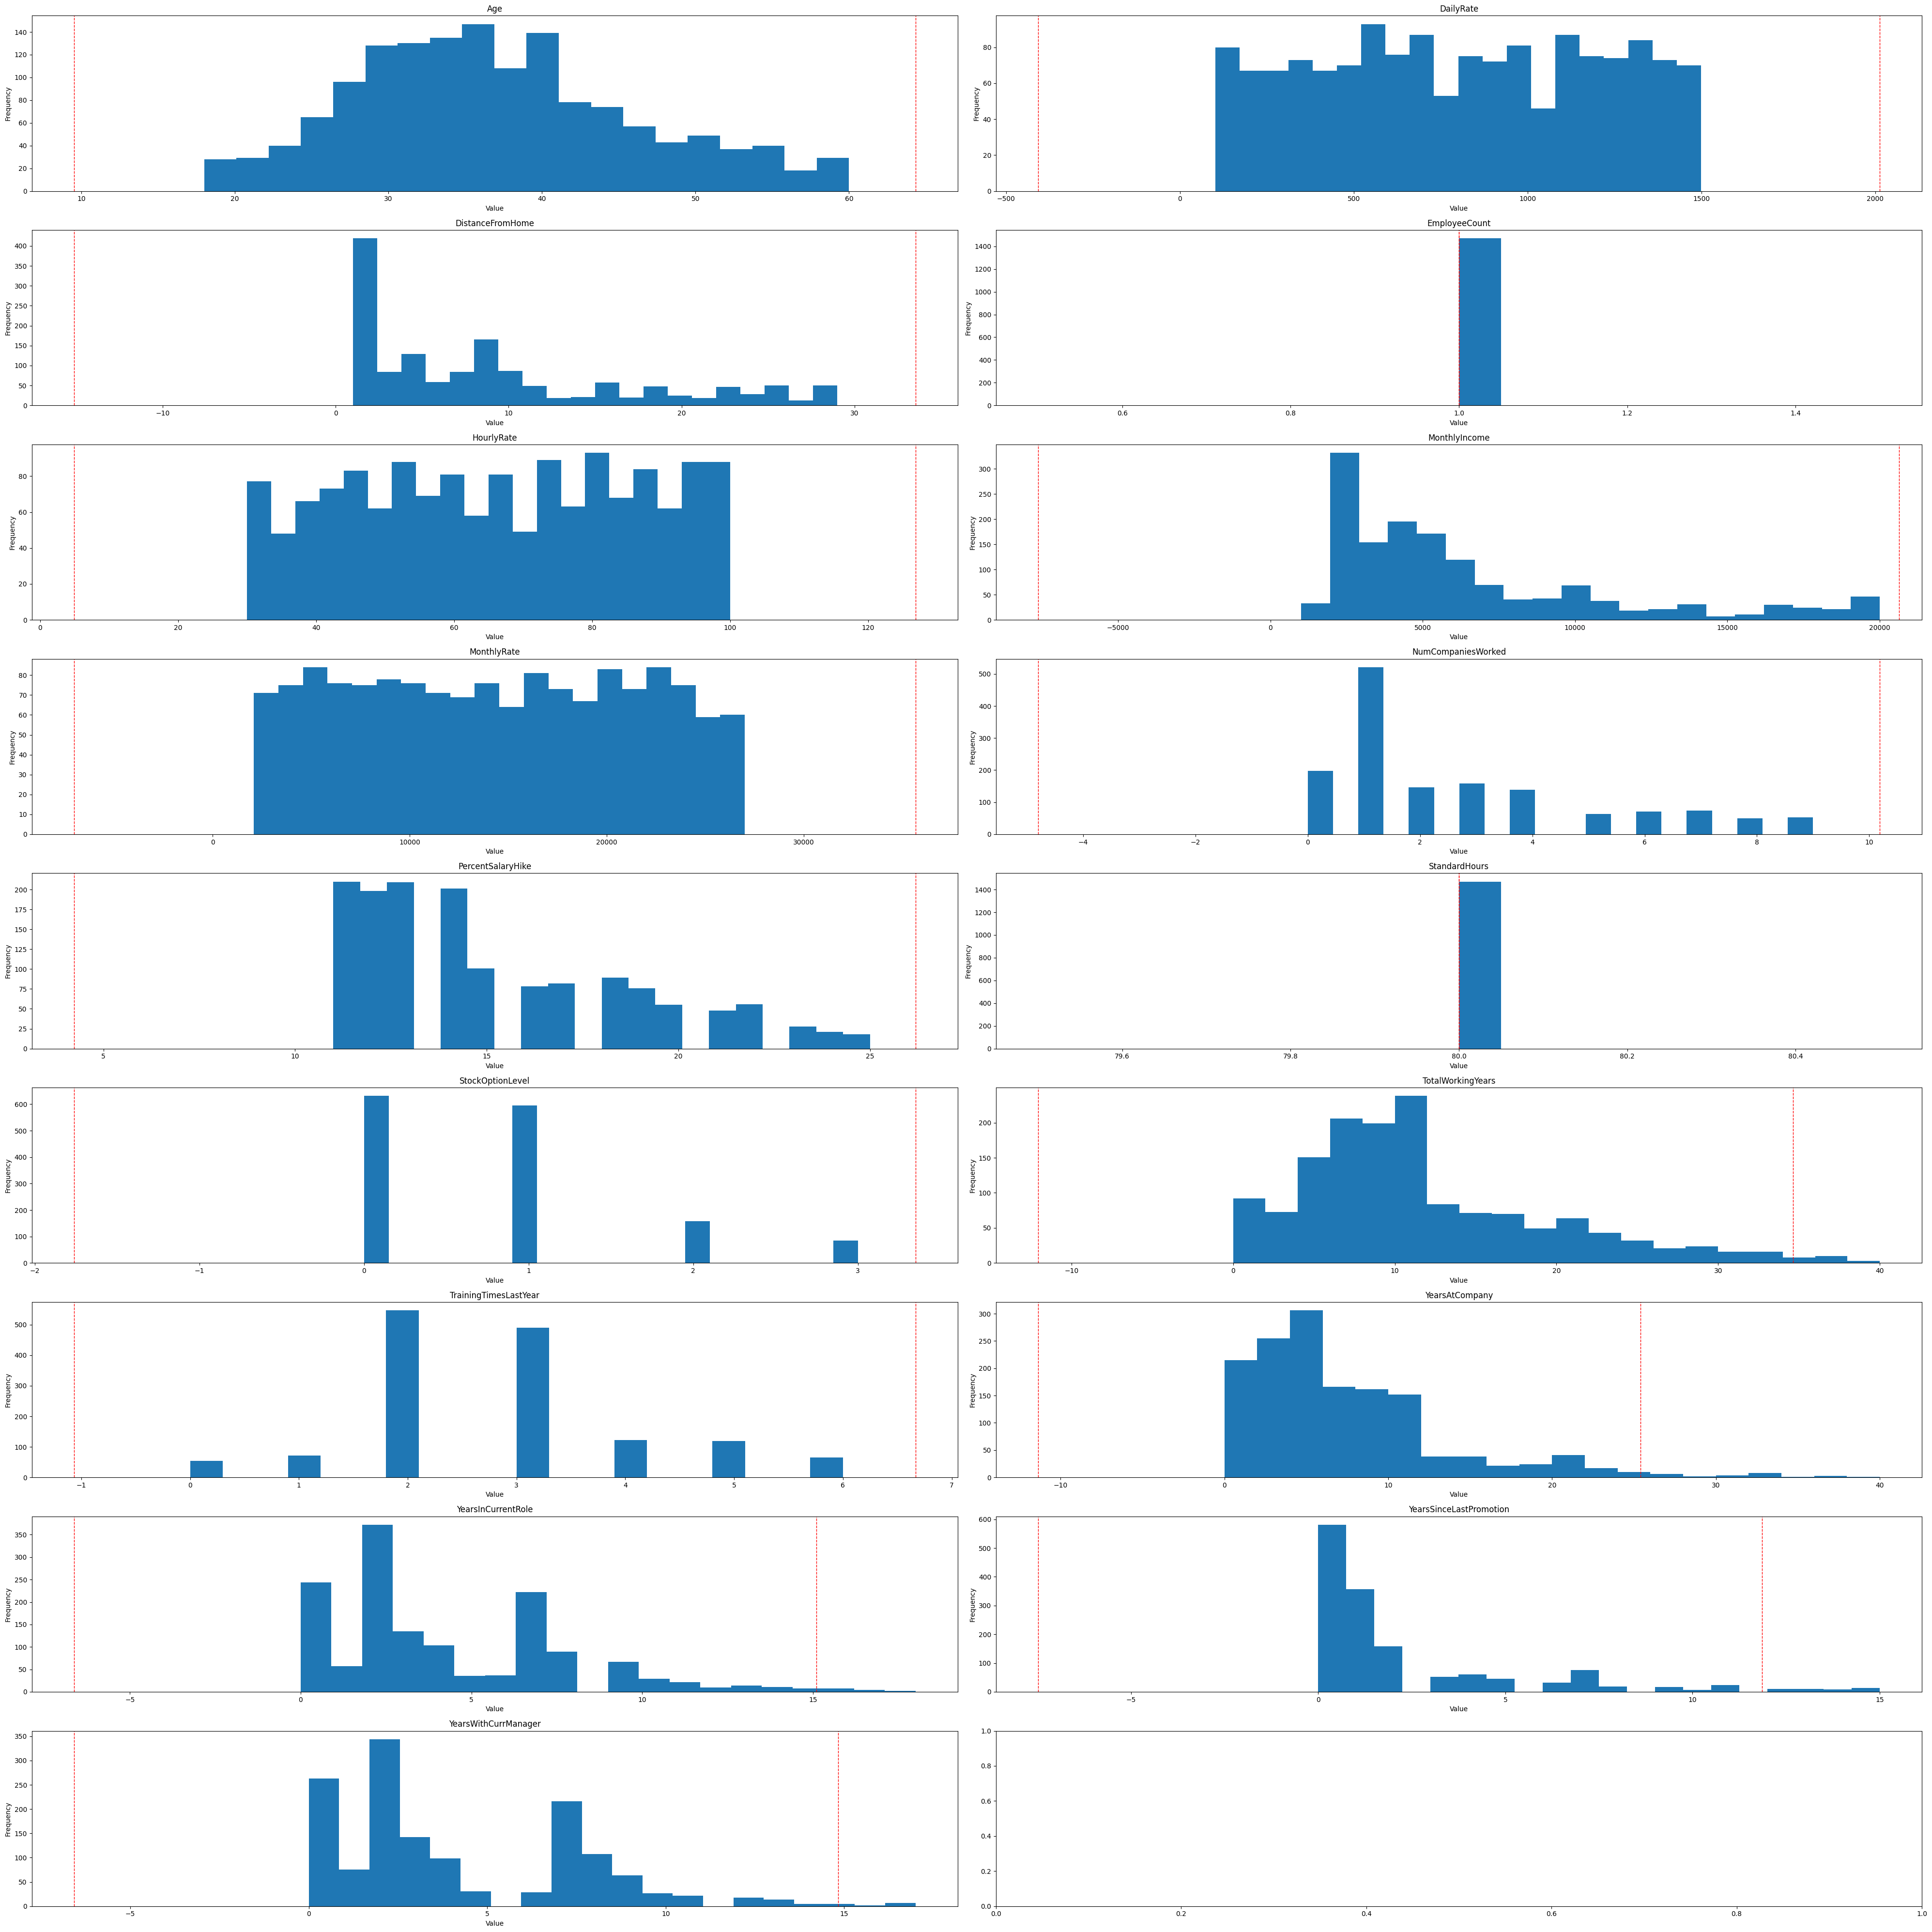

In [105]:
# Plot histogram with the upper and lower limit
fig, axes = plt.subplots(9, 2, figsize=(40, 40))
all_axes = axes.flatten() # Flatten the axes array once

for i in range(len(num_features)): # Iterate only for the count of num_features
    ax = all_axes[i] # Use the current axis
    current_feature = num_features[i] # Get the current feature name

    ax.hist(df[current_feature], bins=20)
    # add lower and upper limits to vizualize the outlier
    ax.axvline(limit_sigma[current_feature][0], color='r', linestyle='dashed', linewidth=1)
    ax.axvline(limit_sigma[current_feature][1], color='r', linestyle='dashed', linewidth=1)
    ax.set_title(current_feature)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()

In [106]:
# Remove outliers from the dataframe
# Get iondex of values in the lower and upper limit
outliers = {}

for num in num_features:
  outliers = df[(df[num] <= limit_sigma[num][0]) | (df[num] >= limit_sigma[num][1])]

# Remove outliers from df

df = df.drop(outliers.index)
print(f"Total outliers removed: {len(outliers)}")

Total outliers removed: 14


### Feature Scaling

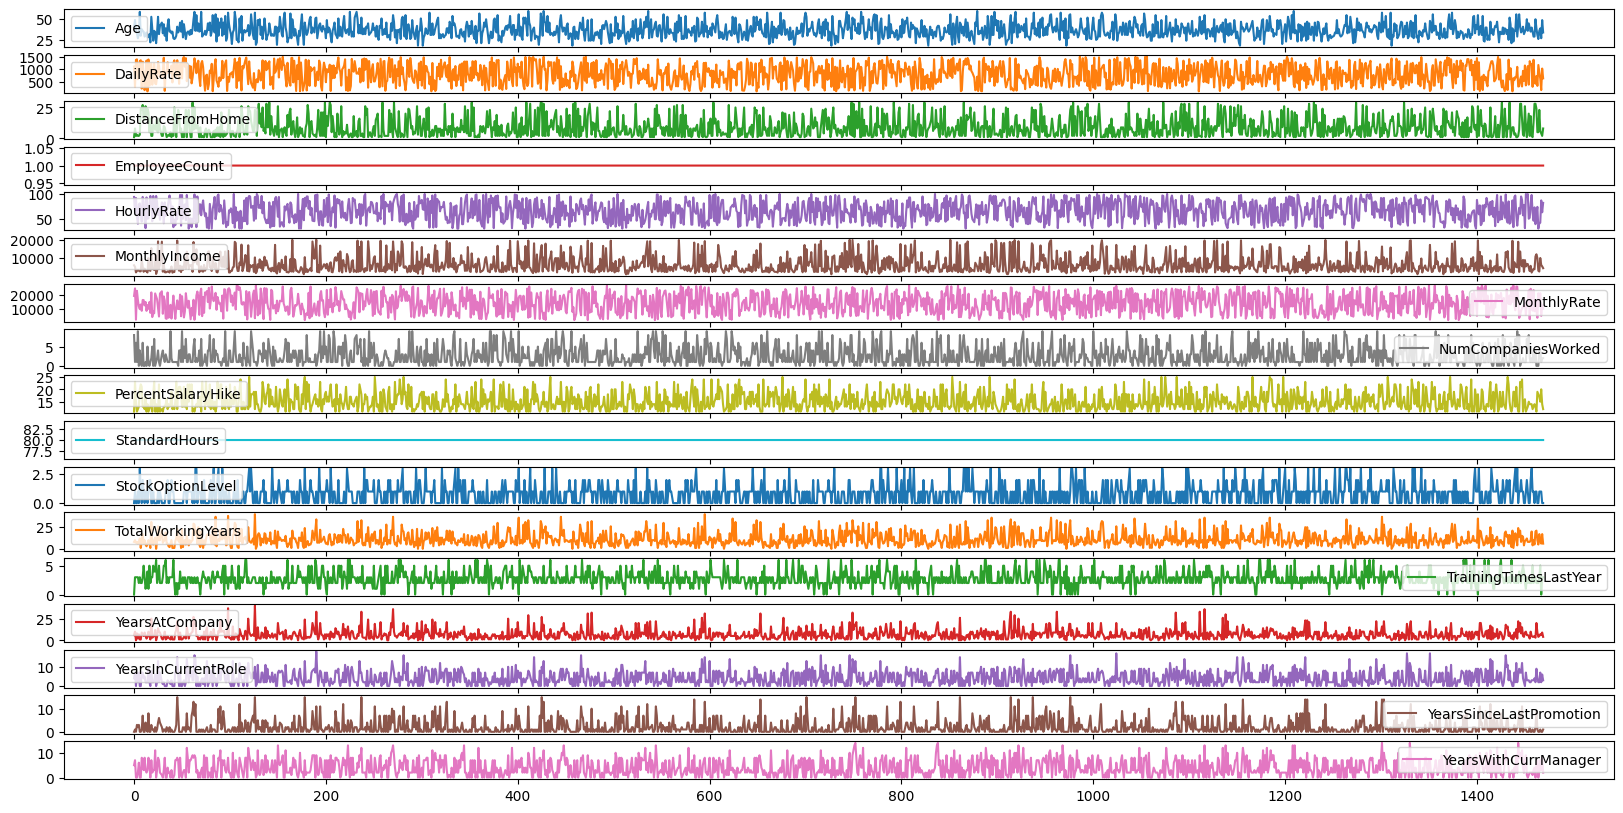

In [107]:
# Compare scales on numerical values

num_features = df.select_dtypes(include=['int64', 'float64']).columns
df[num_features].plot(figsize=(20, 10), subplots=True)
plt.show()

**Feature Scaling Strategy**

After comparason among all the numerical variables we can see that there are some that ranges from 0 to 100, others from 0 to less than 10.
For this reason, we will be using the *Normalization (Min-Max Scaling)* which uses the min and max of each feature to scale the features.

With this approach we will keep the patterns in the data.

*Formula: (x - min) / (max - min)*

In [108]:
# Scale the numerical features using normalization
df_clean = df.copy()
for num in num_features:
  df_clean[num] = (df_clean[num] - df_clean[num].min()) / (df_clean[num].max() - df_clean[num].min())

df_clean[num_features].head()

,Age,DailyRate,DistanceFromHome,EmployeeCount,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.547619,0.715820,0.000000,NaN,0.914286,0.262454,0.698016,0.888889,0.000000,NaN,0.000000,0.200,0.0,0.15,0.222222,0.000000,0.357143
1,0.738095,0.126700,0.250000,NaN,0.442857,0.217009,0.915991,0.111111,0.857143,NaN,0.333333,0.250,0.5,0.25,0.388889,0.066667,0.500000
2,0.452381,0.909807,0.035714,NaN,0.885714,0.056925,0.012007,0.666667,0.285714,NaN,0.000000,0.175,0.5,0.00,0.000000,0.000000,0.000000
3,0.357143,0.923407,0.071429,NaN,0.371429,0.100053,0.845796,0.111111,0.000000,NaN,0.000000,0.200,0.5,0.20,0.388889,0.200000,0.000000
4,0.214286,0.350036,0.035714,NaN,0.142857,0.129489,0.583688,1.000000,0.071429,NaN,0.333333,0.150,0.5,0.05,0.111111,0.133333,0.142857


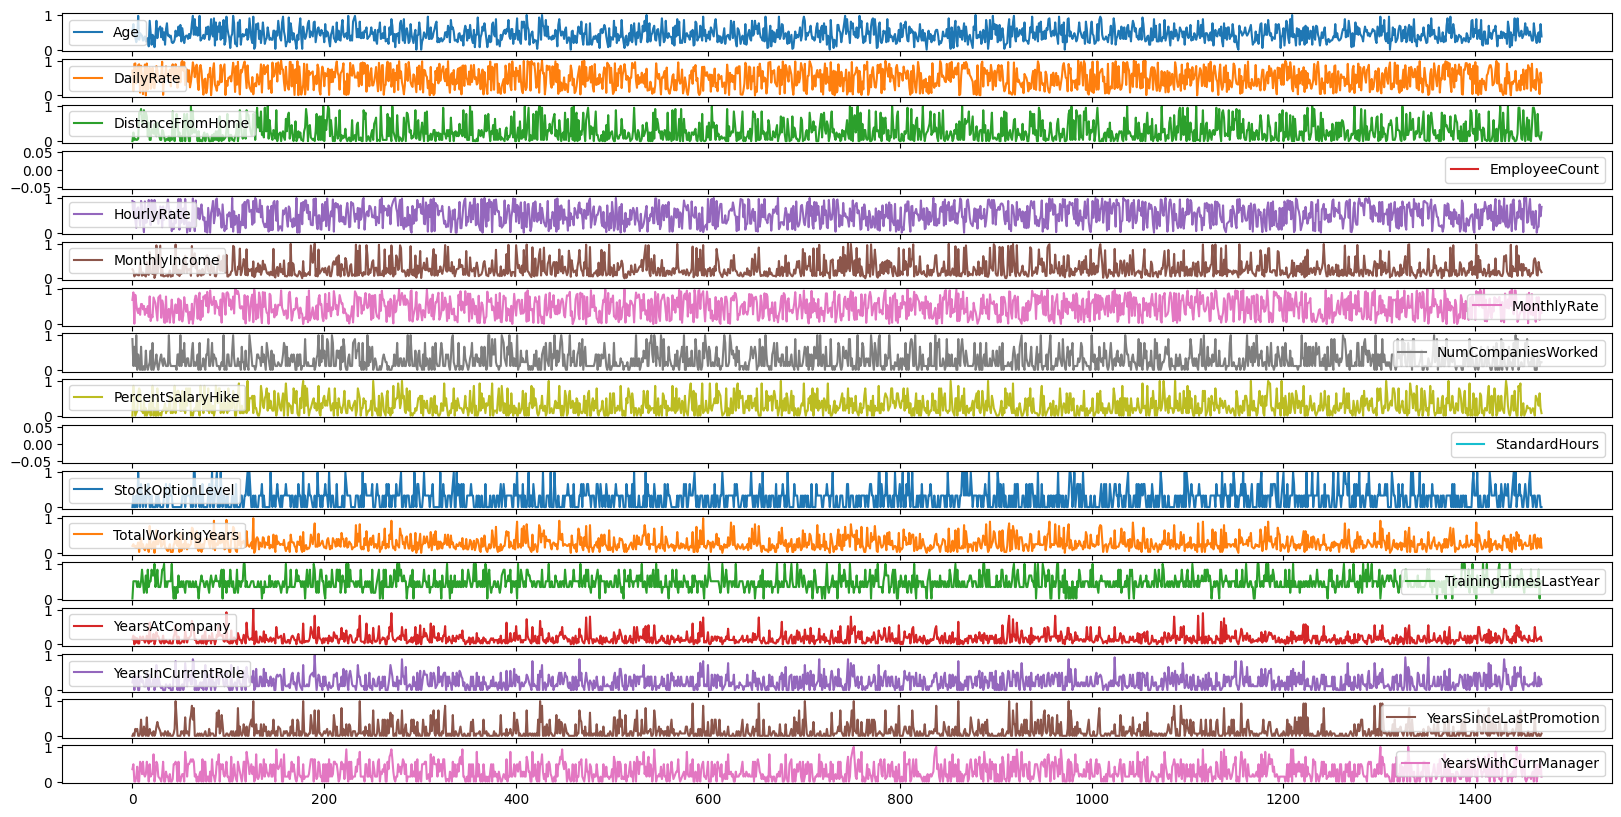

In [109]:
df_clean[num_features].plot(figsize=(20, 10), subplots=True)
plt.show()

## **4. Explore Relationships**
Now that we have a cleaned and preprocessed dataframe, we can explore the feature relationships. Specially how our Y feature "Attrition" is dependent to Categorical and Numerical variables.

We will apply:

1. ANOVA: for Readmittion to Numerical Features
1. Chi-square test: for Readmittion to Categorical Features

#### Relationships: Numerical Features

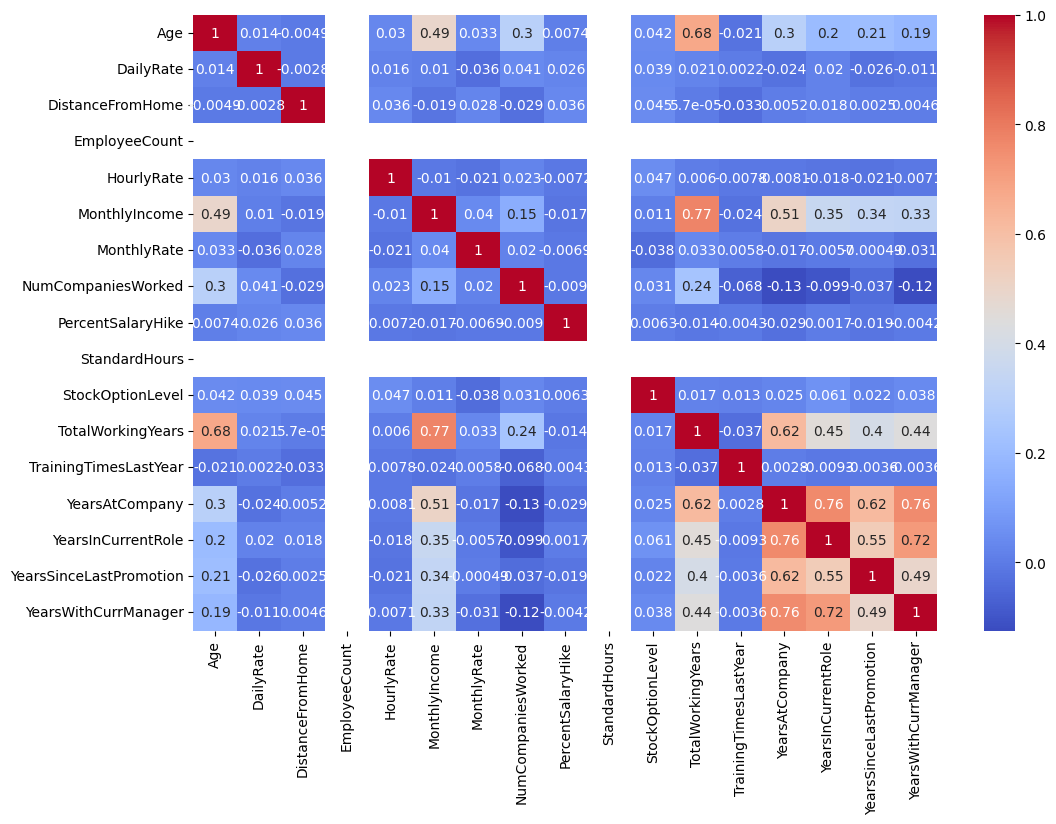

In [110]:
from numpy import size
# Heatmap for numerical features wiht seaborn

# Adjust fig size
fig, ax = plt.subplots(figsize=(12, 8))

corr = df_clean[num_features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=ax)
plt.show()

#### Relationships: Numerical & Attrition

In [111]:
# Set error to alpha 0.05
alpha = 0.05
resultAnova = []

# Iterate categorical features
for num in num_features:
  CategoryGroupList = df_clean.groupby('Attrition')[num].apply(list)
  f_value, p_value = f_oneway(*CategoryGroupList)

  # Check hypotesis using p value
  if p_value < alpha:
    resultAnova.append([num, 'Correlated', p_value, 'num'])
  else:
    resultAnova.append([num, 'Not Correlated', p_value, 'num'])

resultAnova = pd.DataFrame(resultAnova, columns=['Feature', 'Dependency', 'P-value', 'Dtype'])

In [112]:
# review the strongest correlations
resultAnova = resultAnova[resultAnova['Dependency'] == 'Correlated']
resultAnova

,Feature,Dependency,P-value,Dtype
0,Age,Correlated,1.871359e-09,num
1,DailyRate,Correlated,2.428682e-02,num
2,DistanceFromHome,Correlated,2.344777e-03,num
5,MonthlyIncome,Correlated,1.583434e-09,num
10,StockOptionLevel,Correlated,1.000703e-07,num
11,TotalWorkingYears,Correlated,1.462660e-10,num
12,TrainingTimesLastYear,Correlated,2.265631e-02,num
13,YearsAtCompany,Correlated,8.752654e-07,num
14,YearsInCurrentRole,Correlated,1.760084e-09,num
16,YearsWithCurrManager,Correlated,7.651028e-09,num


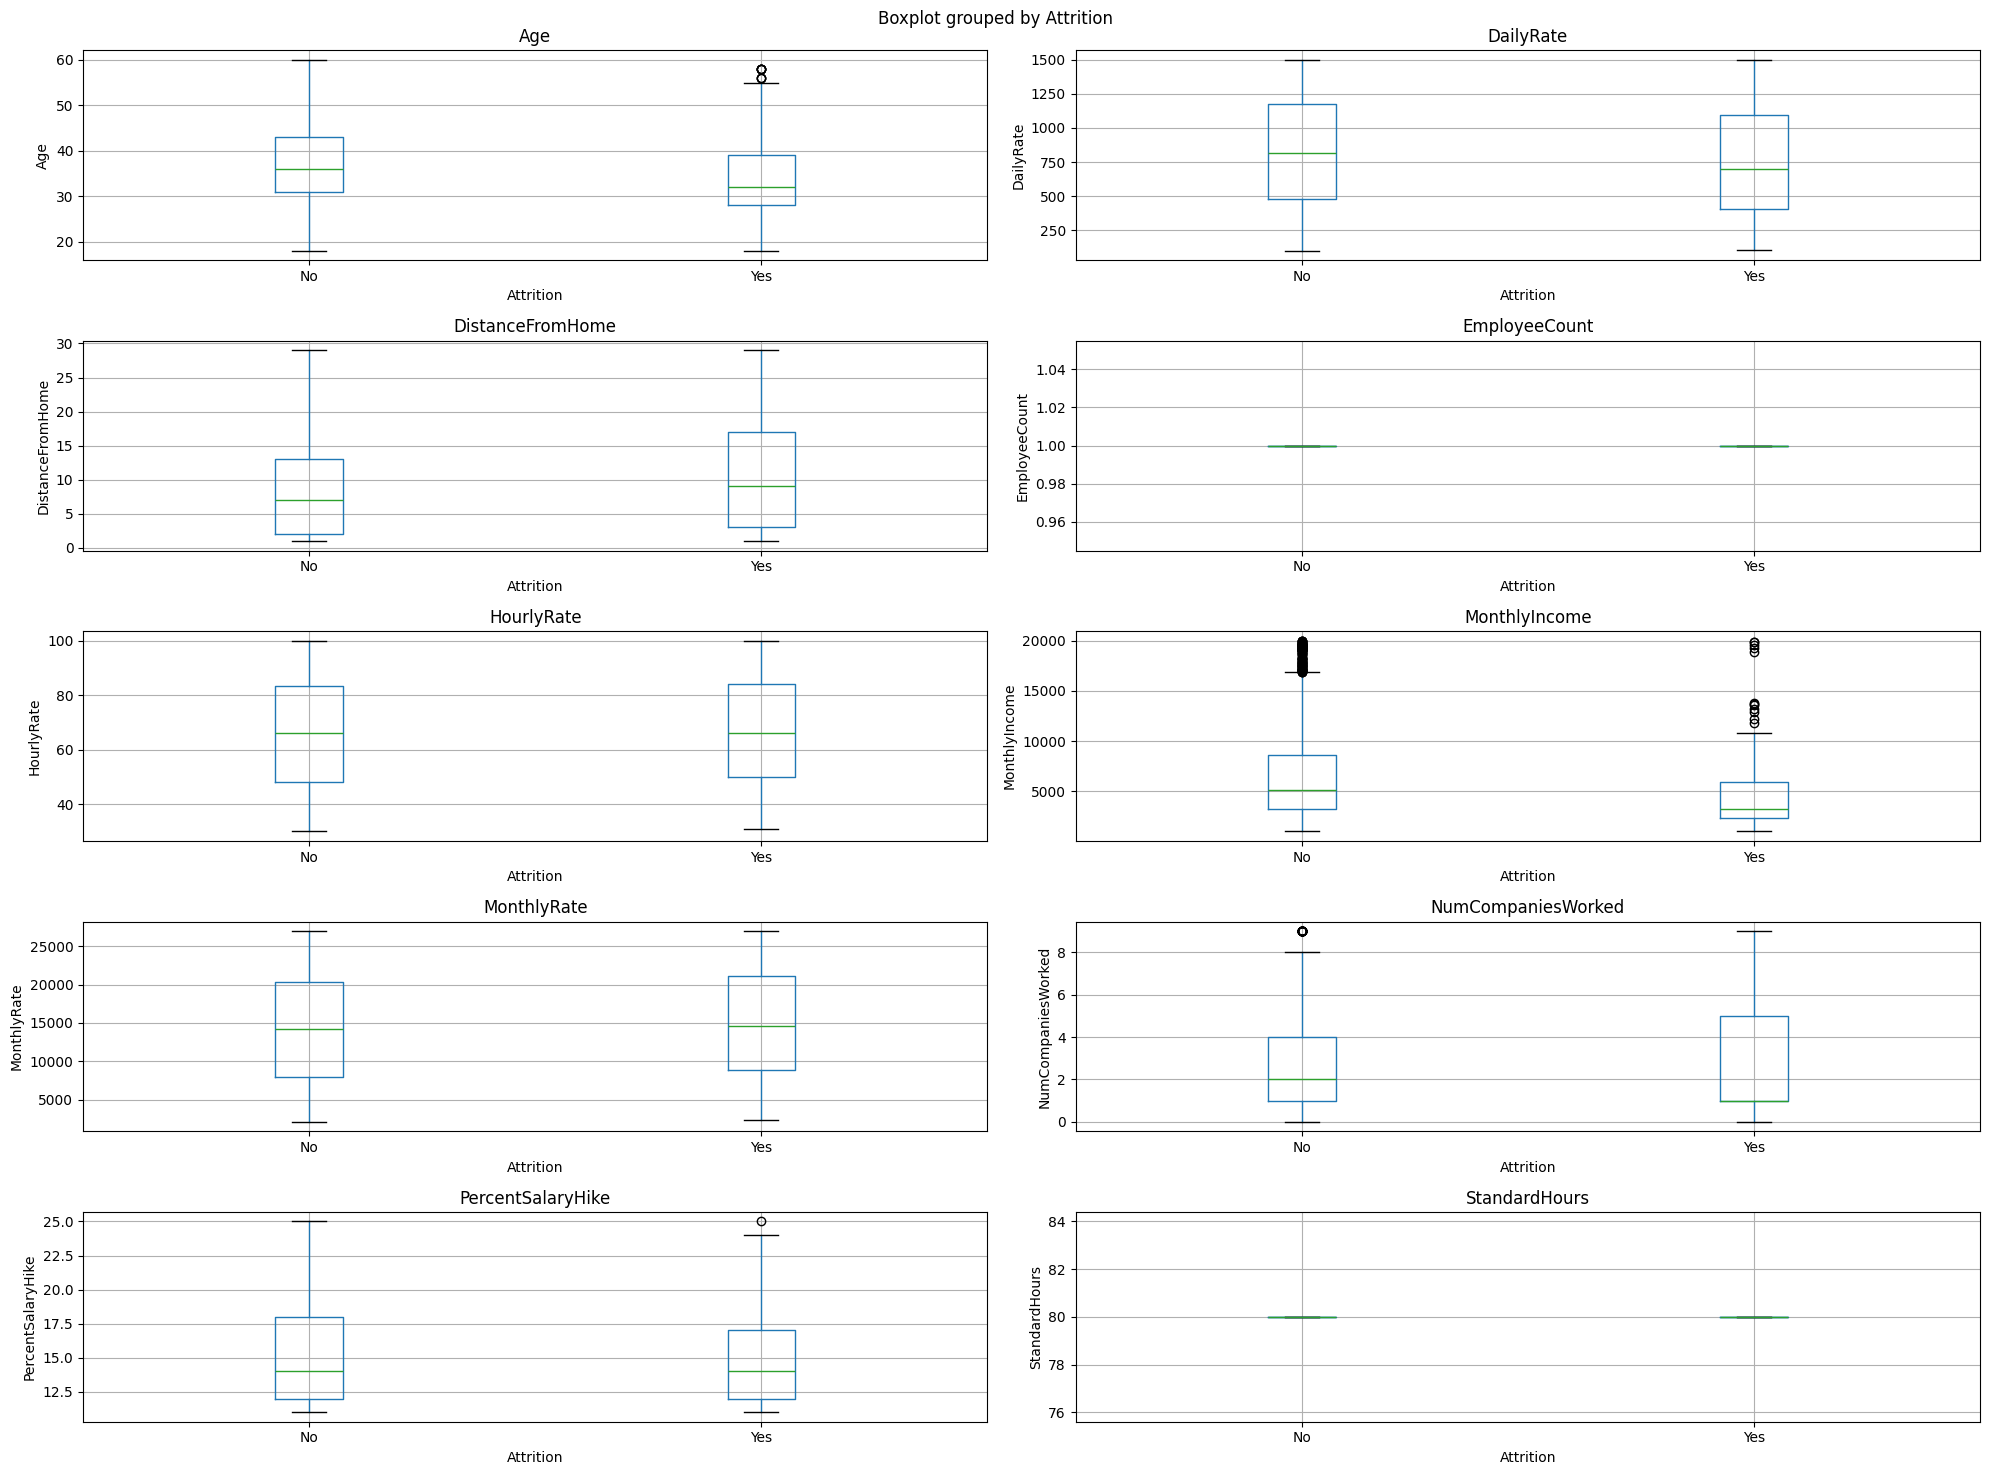

In [113]:
# Plot dependent numerical features with 'Attrition' feature
# Boxplot

fig, axes = plt.subplots(5, 2, figsize=(20, 15))

for i, ax in enumerate(axes.flatten()):
  df.boxplot(column=num_features[i], by='Attrition', ax=ax)
  ax.set_title(num_features[i])
  ax.set_xlabel('Attrition')
  ax.set_ylabel(num_features[i])

plt.tight_layout()
plt.show()

#### Relationships: Categorical & Readmitted

In [114]:
categorical_features = df_clean.select_dtypes(include=['category', 'object']).columns
categorical_features

Index(['Attrition', 'BusinessTravel', 'Department', 'Education',
       'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'Over18', 'OverTime', 'PerformanceRating',
       'RelationshipSatisfaction', 'WorkLifeBalance'],
      dtype='object')

In [115]:
# To make select the best features, we use Chi-square test.
# Null Hypothesis (H0): Two variables are independent
# Alternate Hypothesis (H1): Two variables are not independent

# Create the contingency table

resultChi2 = []
table = []
# Exclude 'Attrition' from the categorical_features list for the chi-square test
for cat in [c for c in categorical_features if c != 'Attrition']:
    table = df[[cat,'Attrition']]
    table = pd.crosstab(table[cat], table['Attrition'])

    stat, p, dof, expected = chi2_contingency(table)

#     interpret test-statistic
    prob = 0.95

#     get critical chi-square
    critical = chi2.ppf(prob, dof)

    if abs(stat) >= critical:
        resultChi2.append([cat, 'Correlated', critical, 'cat'])
    else:
        resultChi2.append([cat, 'No Correlated', critical, 'cat'])

resultChi2 = pd.DataFrame(resultChi2, columns=['Feature', 'Dependency', 'Critical value', 'Dtype'])

resultChi2 = resultChi2.sort_values(by='Critical value', ascending=True)

In [116]:
# review the strongest correlations
resultChi2 = resultChi2[resultChi2['Dependency'] == 'Correlated']
resultChi2

,Feature,Dependency,Critical value,Dtype
13,OverTime,Correlated,3.841459,cat
0,BusinessTravel,Correlated,5.991465,cat
1,Department,Correlated,5.991465,cat
11,MaritalStatus,Correlated,5.991465,cat
7,JobInvolvement,Correlated,7.814728,cat
5,EnvironmentSatisfaction,Correlated,7.814728,cat
16,WorkLifeBalance,Correlated,7.814728,cat
10,JobSatisfaction,Correlated,7.814728,cat
8,JobLevel,Correlated,9.487729,cat
3,EducationField,Correlated,11.070498,cat


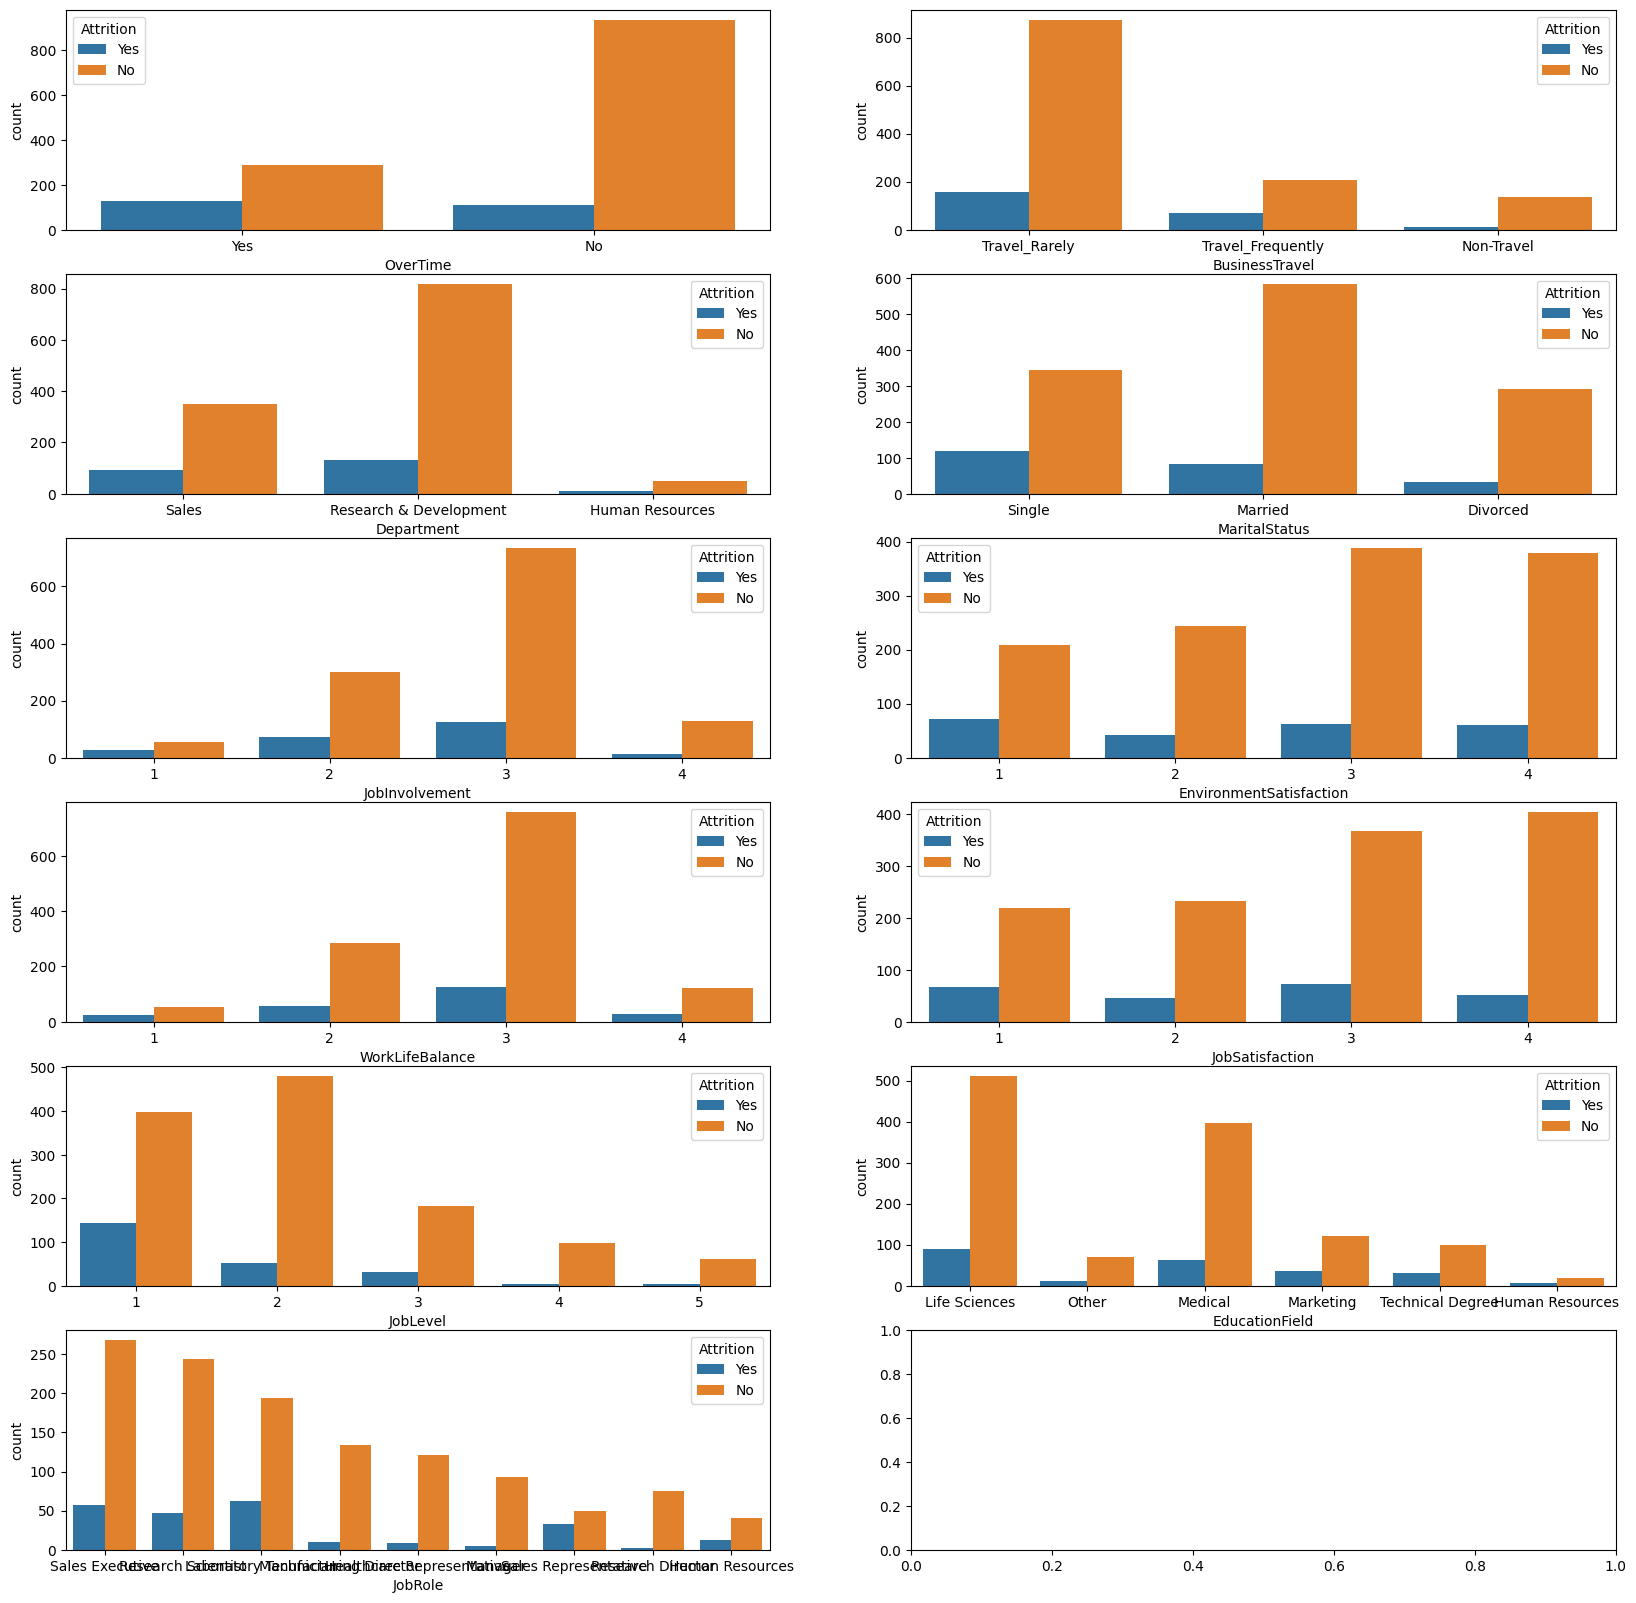

In [122]:
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(20, 20))

for variable, subplot in zip(resultChi2.Feature[resultChi2['Dependency'] == 'Correlated'], axes.flatten()):
  sns.countplot(x=variable, hue='Attrition',data=df_clean, ax=subplot)

In [117]:
print(f'total categrocial features: {len(categorical_features)}\ntotal high dependency features: {len(resultChi2)}')
print(f'total numerical features: {len(num_features)}\ntotal high dependency features: {len(resultAnova)}')

total categrocial features: 18
total high dependency features: 11
total numerical features: 17
total high dependency features: 10


#### **Conclusion of Features Relationship**

1. 61% of the cateforical features are highly correlated to the attrition
2. 58% of the numerical features are highly correlated to the attrition
3. Correlation between numerical features were found but nothing outstanding. Highest correlation: MonthlyIncome vs TotalWorking years.

**Insights for categorical features**
1. **Business Travel:** Employes that travel rarely shows the highest attration rate (~200 employees)
2. **Department:** The department wiht highest attration is "Research & Development" (~150 employees)
3. **Job Level:** Level 1 is the highest with employee attration (~150 employees)


---